Setup and Data Loading

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml

# Loading the Ames Housing dataset (Real-world data)
dataset = fetch_openml(name="house_prices", as_frame=True, parser='pandas')
df = dataset.frame

print(f"Dataset Shape: {df.shape}")
df.head()

Initial Inspection


In [ ]:
# Checking for missing values and general structure
print("--- Missing Values ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

print("\n--- Duplicates ---")
print(f"Duplicate rows: {df.duplicated().sum()}")

df.describe()

Feature Dropping & Selection


In [ ]:
# Dropping columns with too many missing values or irrelevant info
cols_to_drop = ['Id', 'Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu']
df.drop(columns=cols_to_drop, inplace=True)

# Filling a few essential numeric NAs with median to prevent errors before pipeline
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

print("Columns remaining:", len(df.columns))

Columns remaining: 75


Data Encoding (Categorical)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

df_encoded = df.copy()

# 1. One-Hot Encoding for 'MSZoning' (Similar to your Property_Type)
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
zoning_array = ohe.fit_transform(df_encoded[['MSZoning']])
zoning_cols = ohe.get_feature_names_out(['MSZoning'])
df_encoded = pd.concat([df_encoded.drop(columns=['MSZoning']),
                        pd.DataFrame(zoning_array, columns=zoning_cols, index=df_encoded.index)], axis=1)

# 2. Ordinal Encoding for Quality (Similar to your Furnished_Status)
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, np.nan: 0}
df_encoded['ExterQual'] = df_encoded['ExterQual'].map(qual_map)
df_encoded['KitchenQual'] = df_encoded['KitchenQual'].map(qual_map)

# 3. Binary Encoding (Similar to your Security/Parking)
df_encoded['CentralAir'] = df_encoded['CentralAir'].map({'Y': 1, 'N': 0})

# 4. Frequency Encoding for Neighborhood (Similar to your State/City)
neigh_freq = df_encoded['Neighborhood'].value_counts(normalize=True).to_dict()
df_encoded['Neighborhood'] = df_encoded['Neighborhood'].map(neigh_freq)

df_encoded.head()

Winsorize & Log Transform

In [ ]:
# Clipping outliers in Ground Living Area (similar to your Size_in_SqFt)
p_low, p_high = df_encoded['GrLivArea'].quantile([0.01, 0.99])
df_encoded['GrLivArea_clipped'] = df_encoded['GrLivArea'].clip(p_low, p_high)

# Log transformation for Size and Price (Target)
df_encoded['log_size'] = np.log1p(df_encoded['GrLivArea_clipped'])
df_encoded['log_price'] = np.log1p(df_encoded['SalePrice'])

print(f"1st percentile: {p_low}, 99th: {p_high}")

1st percentile: 692.18, 99th: 3123.4800000000023


Feature & Target Selection

In [ ]:
# Selecting a mix of features for the model
features = ['Neighborhood', 'OverallQual', 'OverallCond', 'YearBuilt', 'log_size',
            'FullBath', 'BedroomAbvGr', 'KitchenQual', 'ExterQual', 'CentralAir',
            'MSZoning_RL', 'MSZoning_RM', 'MSZoning_FV']

X = df_encoded[features]
y = df_encoded['log_price']

print("X shape:", X.shape)
display(X.head(3))

X shape: (1460, 13)


,Neighborhood,OverallQual,OverallCond,YearBuilt,log_size,FullBath,BedroomAbvGr,KitchenQual,ExterQual,CentralAir,MSZoning_RL,MSZoning_RM,MSZoning_FV
0,0.102740,7,5,2003,7.444833,2,3,4,4,1,1.0,0.0,0.0
1,0.007534,6,8,1976,7.141245,2,3,3,3,1,1.0,0.0,0.0
2,0.102740,7,5,2001,7.488294,2,3,4,4,1,1.0,0.0,0.0


Train/Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 1168
Testing set size: 292


Pipeline + Baseline Random Forest

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

# Preprocessing: Fill any missed NAs and scale
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), features)
    ]
)

# Initialize Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# Full Pipeline
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', rf_model)
])

print("Pipeline constructed successfully.")

Pipeline constructed successfully.


Train Model

In [ ]:
import time

start = time.time()
pipeline.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Training finished in {elapsed:.2f} seconds.")

Training finished in 0.74 seconds.


Evaluation (Log and Original Scales)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Predictions in log scale
y_pred_log = pipeline.predict(X_test)

# 2. Convert back to original currency (USD for Ames)
y_pred = np.expm1(y_pred_log)
y_true = np.expm1(y_test)

mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
r2 = r2_score(y_true, y_pred)

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)
print(f"MAE:  ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")
print("=" * 50)

MODEL EVALUATION
MAE:  $19,169.85
RMSE: $29,048.89
R² Score: 0.8900


Evaluation Plots

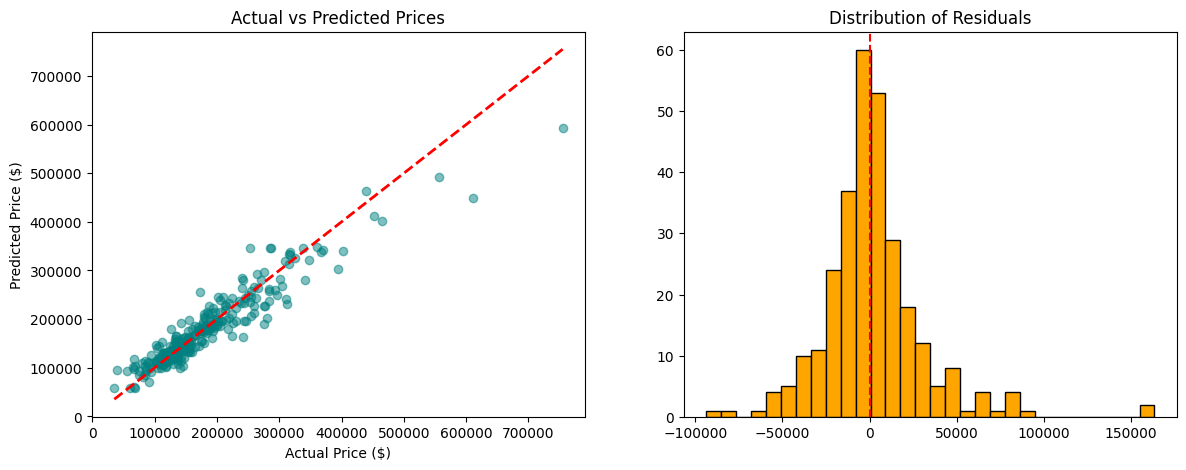

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Actual vs Predicted
axes[0].scatter(y_true, y_pred, alpha=0.5, color='teal')
axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
axes[0].set_title('Actual vs Predicted Prices')
axes[0].set_xlabel('Actual Price ($)')
axes[0].set_ylabel('Predicted Price ($)')

# Residuals
residuals = y_true - y_pred
axes[1].hist(residuals, bins=30, color='orange', edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_title('Distribution of Residuals')
plt.show()

Cross-Validation

In [ ]:
from sklearn.model_selection import cross_val_score

# Performing CV on the log scale for stability
cv_scores = cross_val_score(pipeline, X, y, cv=5, scoring='r2')

print(f"5-Fold CV R² Scores: {cv_scores}")
print(f"Mean CV R²: {cv_scores.mean():.4f}")

5-Fold CV R² Scores: [0.84028836 0.83916892 0.83909458 0.86324287 0.84349466]
Mean CV R²: 0.8451


Feature Importance

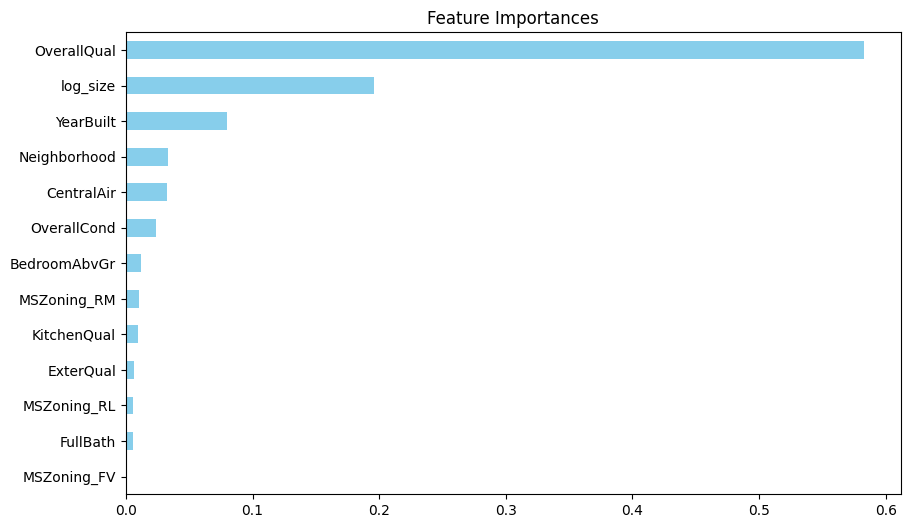

In [ ]:
importances = pipeline.named_steps['model'].feature_importances_
feat_imp = pd.Series(importances, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
ax = feat_imp.plot(kind='barh', color='skyblue')
ax.set_title('Feature Importances')
ax.invert_yaxis() # Invert y-axis on the Axes object
plt.show()

Hyperparameter Tuning & Save

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import joblib

param_dist = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__max_features': ['sqrt', 'log2']
}

rs = RandomizedSearchCV(pipeline, param_dist, n_iter=10, cv=3, random_state=42)
rs.fit(X_train, y_train)

# Save the best model
joblib.dump(rs.best_estimator_, 'ames_housing_model.joblib')
print(f"Best R² from tuning: {rs.best_score_:.4f}")
print("Model saved as ames_housing_model.joblib")

Best R² from tuning: 0.8464
Model saved as ames_housing_model.joblib


In [ ]:
import joblib

# Saved trained model
joblib.dump(rf_model, "logistic_model.pkl")

# Saved feature column order
joblib.dump(X.columns, "feature_columns.pkl")

print("Model, Scaler and Columns Saved Successfully!")